In [361]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [362]:
# 3 Kepler's Third La

In [363]:
df = pd.read_csv("../../../python_decal_fa25/course_assignments/homework9/solar_system.csv")
df

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [364]:
# 3.4
print(df.shape)
# 20 columns and 11 rows
print(df.head())
print(df.tail())
print(df.columns)
print(df['Attribute'])

(20, 11)
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0     1    0     2       95      274   
18             Ring Sy

In [365]:
# 3.5 
df2 = df.iloc[:, 1:]
orbital_period = df2.iloc[10].astype(float)
perihelion = df2.iloc[8].astype(float)
aphelion = df2.iloc[9].astype(float)

In [366]:
# 3.6
# perihelion = The point of an objects orbit when it is the closest distance from thte object it is orbiting
# aphelion = The point of an objects orbit when it is furthest distance from the object it is orbiting
# sem-major axis = The average between the perihelion and apehelion

In [367]:
# 3.7
semi_major_axis = (perihelion + aphelion) / 2
semi_major_axis # Units = (10^6 km)

Mercury      57.9000
Venus       108.2000
Earth       149.6000
Moon          0.3845
Mars        228.0000
Jupiter     778.5000
Saturn     1432.0500
Uranus     2867.0500
Neptune    4515.0000
Pluto      5906.3500
dtype: float64

In [368]:
# 3.8
semi_data = pd.DataFrame(
    {'Attribute': ['Semi Major Axis (10^6 km)'], 
     'Mercury': [57.9000], 
     'Venus': [108.2000], 
     'Earth': [149.6000], 
     'Moon': [0.3845], 
     'Mars': [228.0000], 
     'Jupiter': [778.5000], 
     'Saturn': [1432.0500], 
     'Uranus': [2867.0500], 
     'Neptune': [4515.0000], 
     'Pluto': [5906.3500],
    },
     index = [20]
    )
df2 = pd.concat([df, semi_data])

In [369]:
# 3.9
print(df2.shape)
# 21 rows and 11 columns
df2

(21, 11)


,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


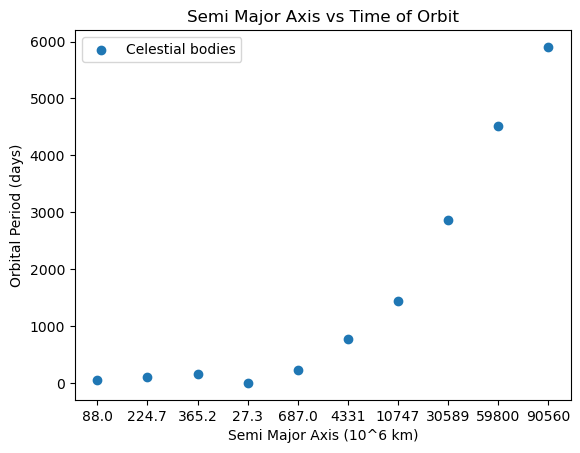

In [370]:
# 3.10
df3 = df2.drop(df2.columns[0], axis = 1)
x = df3.iloc[10].values
y = df3.iloc[20].values
plt.figure()
plt.scatter(x, y, label = 'Celestial bodies')
plt.xlabel('Semi Major Axis (10^6 km)')
plt.ylabel('Orbital Period (days)')
plt.legend()
plt.title('Semi Major Axis vs Time of Orbit')
plt.show()

In [371]:
# 3.11
x = df3.iloc[10].values
def keplers_third_law(a, m):
    return m * a ** 1.5           # This returns orbital period  
                                  # m is the constants stuff
                                  # a is the semi major axis (THIS IS x)
keplers_third_law(x.astype(float), m_fit.item())
# print(x) 
# print(m_fit[0])

array([2.04309338e-01, 8.33621326e-01, 1.72727052e+00, 3.53027208e-02,
       4.45655544e+00, 7.05417913e+01, 2.75737022e+02, 1.32407360e+03,
       3.61922834e+03, 6.74479615e+03])

In [372]:
# 3.12-15
a = x
p0 = [1]
popt, pcov = curve_fit(keplers_third_law, a, y, p0=p0) 
m_fit = popt
f"Fit: y = {m_fit[0]:.2f} * a ** 1.5"
residuals = y - keplers_third_law(a.astype(float), m_fit.item())
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = f"{chi2 / dof:.2f}"
chi2_reduced

'645681.55'

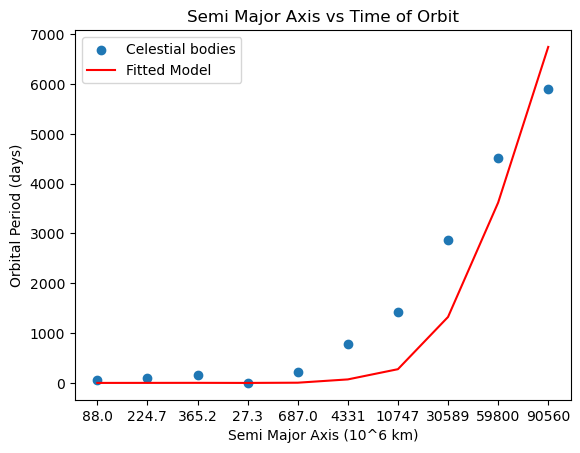

In [373]:
# 3.16
plt.figure()
plt.scatter(x, y, label = 'Celestial bodies')
plt.plot(x, keplers_third_law(a.astype(float), m_fit.item()), c = "red", label = 'Fitted Model')
plt.xlabel('Semi Major Axis (10^6 km)')
plt.ylabel('Orbital Period (days)')
plt.legend()
plt.title('Semi Major Axis vs Time of Orbit')
plt.show()

In [374]:
data = {
    'Plot': ['Semi Major Axis vs Time of Orbit'],
    'm Fit': [m_fit.item()],
    'Reduced Chi-Squared': [chi2_reduced],
}
df = pd.DataFrame(data)
df.to_csv("kepler.csv", index=False)